In [11]:
from torch.utils.data import Dataset
from torch import nn
import os

In [12]:
class Boot_Rotate_Dataset(Dataset):
  def __init__(self,path):
    super(Boot_Rotate_Dataset,self).__init__()

    dirs=[os.path.join(path,dir) for dir in os.listdir(path)]

    self.all_images=[]
    for dir in dirs:
      images=[os.path.join(dir,img) for img in os.listdir(dir) if 'done' in img]
      self.all_images+=images

    self.trans=transforms.Compose([

        transforms.Resize((762,1100))
    ])
    self.tensor_trans=transforms.Compose([

        transforms.Resize((762,1100)),
        transforms.ToTensor()
    ])


  def __len__(self):
    return len(self.all_images)

  def __getitem__(self,idx):

    img=Image.open(self.all_images[idx])

    if randint(0,1):
      degr=randint(0,10)
      img=img.rotate(degr,expand=True)
      #img=self.trans(img)
      new_width,new_height=(610,932)

    else:
      degr=randint(350,360)
      img=img.rotate(degr,expand=True)
      #img=self.trans(img)
      new_width,new_height=(610,932)

    width,height=img.size
    left=(width-new_width)//2
    top=(height-new_height)//2
    right=left+new_width
    bottom=top+new_height
    img=img.crop((left,top,right,bottom))
    tensor_img=self.tensor_trans(img)
    return {
        "img": tensor_img,
        "label":torch.FloatTensor([degr])
        }

In [13]:
def Train_degr_model(model,dataloader,loss_func,optimizer,device):
    #loss_item=0#костыль
    model=model.to(device)
    sigm=nn.Sigmoid()
    for batch in (pbar:=tqdm(dataloader)):
        optimizer.zero_grad()
        pred=sigm(model(batch['img'].to(device)))
        #print(pred,batch['label'])


        loss=loss_func(pred,batch['label'].to(device))
        loss_item=loss.item()
        loss.backward()
        optimizer.step()
        pbar.set_description(f'loss: {loss_item}')
        try:
            torch.save(model.state_dict(),f'/content/drive/My Drive/Colab Notebooks/degr_net_{device}.pth')
        except:
            print('ошибка сохранения весов')

In [14]:
class Degree_Net(nn.Module):
  def __init__(self,input_size,hidden_size):
    super(Degree_Net,self).__init__()

    self.lay0=nn.Sequential(
        nn.Conv2d(input_size,hidden_size,3),
        nn.ReLU(),
        nn.BatchNorm2d(hidden_size,hidden_size),
        nn.MaxPool2d(3,3)
    )

    self.lay1=nn.Sequential(
        nn.Conv2d(hidden_size,hidden_size*2,3),
        nn.ReLU(),
        nn.BatchNorm2d(hidden_size*2,hidden_size*2),
        nn.MaxPool2d(3,3)
    )

    self.lay2=nn.Sequential(
        nn.Conv2d(hidden_size*2,hidden_size*4,3),
        nn.ReLU(),
        nn.BatchNorm2d(hidden_size*4,hidden_size*4),
        nn.MaxPool2d(3,3)
    )

    self.linear_lay=nn.Sequential(
        nn.Flatten(),
        nn.Linear(3214080,128),
        nn.ReLU(),
        nn.Linear(128,1)
    )

  def forward(self,x):
    print(x.shape)
    x0=self.lay0(x)
    print(x0.shape)

    x1=self.lay1(x0)
    print(x1.shape)

    x2=self.lay2(x1)
    print(x2.shape)

    final_x=self.linear_lay(x2)
    print(final_x.shape)

    return final_x

In [16]:
degr_dataset=Boot_Rotate_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData')
degr_dataloader=DataLoader(degr_dataset,batch_size=4,shuffle=True,drop_last=True)

NameError: name 'transforms' is not defined

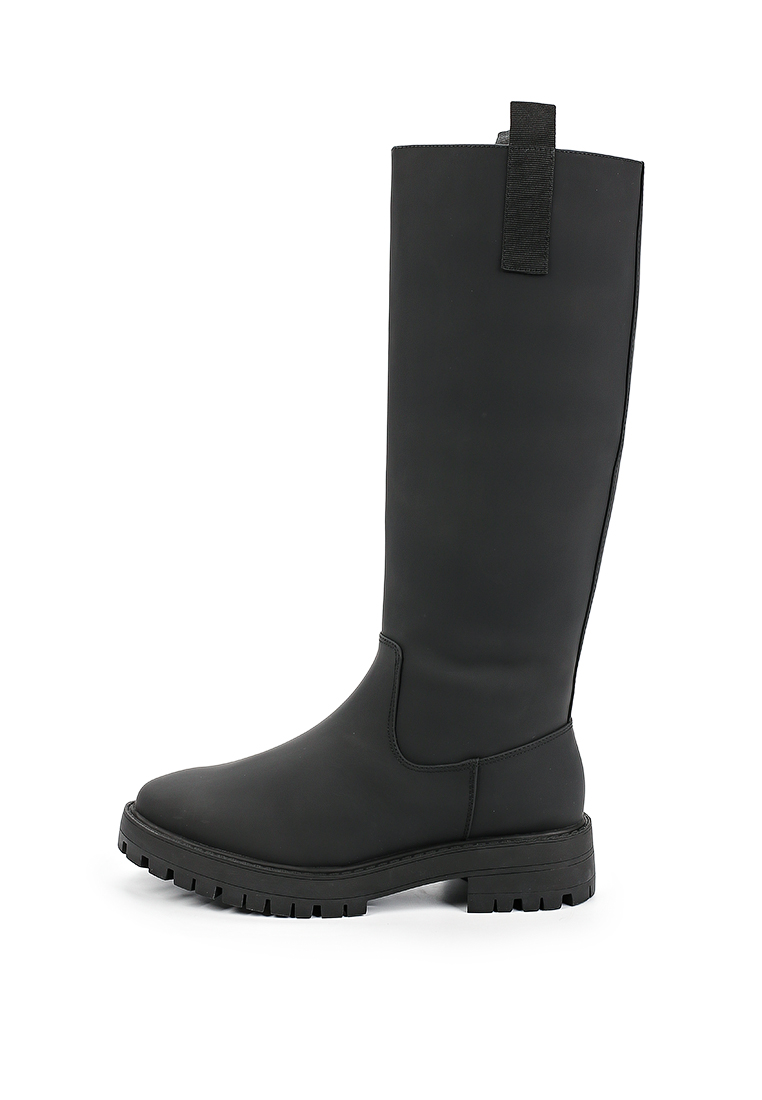

In [10]:
dataset[3001]['done_img']